# Data Cleaning and Chronological Split

This notebook prepares the IPEDS panel for feature engineering. It loads the source data, removes deterministic exclusions and leakage, builds the labeled modeling table, and creates a forward-year train/validation/test split.

> **Target:** `TARGET_STAFF_CUT` is a **two-year** forward label — a ≥5% decline in instructional FTE staff over `t → t+2` — built upstream in `master_panel_df.csv`. This notebook consumes it and stays target-agnostic apart from the leakage list below.

## 0. Imports and settings

In [21]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

**Setup.** Imports pandas and numpy and widens the display limits so the wide IPEDS tables print in full while inspecting.

## 1. Load the data

In [2]:
df = pd.read_csv("../Data/master_panel_df.csv", low_memory=False)

# Some yearly files carried trailing spaces in a few headers (e.g. "SFTEPTMM   "),
# which the concat left as separate columns. Strip the names and keep the first.
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.duplicated()]

print("shape:", df.shape)
df.head()

shape: (8670, 551)


,UNITID,INSTNM,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,GENTELE,EIN,OPEID,OPEFLAG,WEBADDR,ADMINURL,FAIDURL,APPLURL,NPRICURL,VETURL,ATHURL,SECTOR,ICLEVEL,CONTROL,HLOFFER,UGOFFER,GROFFER,HDEGOFR1,DEGGRANT,HBCU,HOSPITAL,MEDICAL,TRIBAL,LOCALE,OPENPUBL,ACT,NEWID,DEATHYR,CLOSEDAT,CYACTIVE,POSTSEC,PSEFLAG,PSET4FLG,RPTMTH,IALIAS,INSTCAT,CCBASIC,CCIPUG,CCIPGRAD,CCUGPROF,CCENRPRF,CCSIZSET,CARNEGIE,LANDGRNT,INSTSIZE,CBSA,CBSATYPE,CSA,NECTA,F1SYSTYP,F1SYSNAM,F1SYSCOD,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG,XF1A01,F1A01,XF1A31,F1A31,XF1A04,F1A04,XF1A05,F1A05,XF1A06,F1A06,XF1A07,F1A07,XF1A08,F1A08,XF1A09,F1A09,XF1A10,F1A10,XF1A11,F1A11,XF1A12,F1A12,XF1A13,F1A13,XF1A14,F1A14,XF1A15,F1A15,XF1A16,F1A16,XF1A17,...,XF1C19DP,F1C19DP,XF1C19IN,F1C19IN,XF1C19OT,F1C19OT,C18BASIC,C18IPUG,C18IPGRD,C18UGPRF,C18ENPRF,C18SZSET,XF1M05,F1M05,XF1M06,F1M06,XF1M07,F1M07,XF1M08,F1M08,F1MHOP,XF1E12,F1E12,XF1E121,F1E121,XF1E122,F1E122,XF1E13,F1E13,XF1E131,F1E131,XF1E132,F1E132,XF1E14,F1E14,XF1E141,F1E141,XF1E142,F1E142,XF1E15,F1E15,XF1E151,F1E151,XF1E152,F1E152,XF1E16,F1E16,XF1E161,F1E161,XF1E162,F1E162,XF1E17,F1E17,XF1E171,F1E171,XF1E172,F1E172,XF1H03,F1H03,XF1H03A,F1H03A,XF1H03B,F1H03B,XF1H03C,F1H03C,XF1H03D,F1H03D,XF1N01,F1N01,XF1N02,F1N02,XF1N03,F1N03,XF1N04,F1N04,XF1N05,F1N05,XF1N06,F1N06,XF1N07,F1N07,C21BASIC,C21IPUG,C21IPGRD,C21UGPRF,C21ENPRF,C21SZSET,UEIS,C00CARNEGIE,CARNEGIEIC,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,FTE_INST_PCT_CHANGE_2Y,FTE_TOTL_PCT_CHANGE_2Y,TARGET_STAFF_CUT,TARGET_VULNERABLE_TOTAL
0,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,2563725000,636001109,100200.0,1,www.aamu.edu/,www.aamu.edu/admissions/pages/default.aspx,www.aamu.edu/Admissions/fincialaid/Pages/defau...,www.aamu.edu/Admissions/apply/Pages/default.aspx,galileo.aamu.edu/netpricecalculator/npcalc.htm,,www.aamu.edu,1,1,1,9,1,1,12,1,1,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,AAMU,2,18.0,13.0,18.0,9.0,4.0,14.0,16.0,1,3,26620,1,290,-2.0,2,,-2,1089,Madison,105,-86.568502,34.783368,131,1,R,76015628.0,R,103355825.0,R,3979751.0,R,107335576.0,R,183351204.0,R,3420000.0,R,52416654.0,R,55836654.0,R,46351285.0,R,0.0,R,46351285.0,R,102187939.0,R,52646385.0,R,17608547.0,R,0.0,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.599190,6.549118,0.0,0.0
1,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,2563725000,636001109,100200.0,1,www.aamu.edu/,www.aamu.edu/admissions/pages/default.aspx,www.aamu.edu/Admissions/fincialaid/Pages/defau...,www.aamu.edu/admissions/undergraduateadmission...,galileo.aamu.edu/netpricecalculator/npcalc.htm,,www.aamu.edu,1,1,1,9,1,1,12,1,1,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,AAMU,2,18.0,NaN,NaN,NaN,NaN,NaN,16.0,1,3,26620,1,290,-2.0,2,,-2,1089,Madison County,105,-86.568502,34.783368,135,1,R,78535712.0,R,115726368.0,R,13423.0,R,115739791.0,R,194275503.0,R,1623631.0,R,62725127.0,R,64348758.0,R,60180723.0,R,65496062.0,R,125676785.0,R,190025543.0,R,57082083.0,R,639990.0,R,0.0,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.659498,3.485577,0.0,0.0
2,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,2563725000,636001109,100200.0,1,www.aamu.edu/,www.aamu.edu/Admissions/Pages/d

## 2. Configuration (AI-Assisted)

In [3]:
TARGET = "TARGET_STAFF_CUT"
KEYS = ["UNITID", "YEAR"]

# Columns computed with future (t+1 or t+2) information or representing another
# forward label. The target now spans t -> t+2, so BOTH the one-year and two-year
# change columns leak and are removed.
LEAKAGE = [
    "FTE_INST_PCT_CHANGE",       # 1-year change (within the 2-year label window)
    "FTE_TOTL_PCT_CHANGE",
    "FTE_INST_PCT_CHANGE_2Y",    # 2-year change = the target itself, pre-threshold
    "FTE_TOTL_PCT_CHANGE_2Y",
    "TARGET_VULNERABLE_TOTAL",
]

# Identifiers, administrative fields, redundant geography, high-cardinality
# codes, and overlapping institutional classifications.
ADMIN = [
    # Institution names, addresses, contacts, and identifiers
    "INSTNM",
    "IALIAS",
    "ADDR",
    "CITY",
    "ZIP",
    "LATITUDE",
    "LONGITUD",
    "CHFNM",
    "CHFTITLE",
    "GENTELE",
    "EIN",
    "OPEID",
    "DUNS",
    "UEIS",

    # URLs
    "WEBADDR",
    "ADMINURL",
    "FAIDURL",
    "APPLURL",
    "NPRICURL",
    "VETURL",
    "ATHURL",
    "DISAURL",

    # Names and dates
    "COUNTYNM",
    "F1SYSNAM",
    "CLOSEDAT",

    # Administrative status and reporting fields
    "ACT",
    "OPEFLAG",
    "PSET4FLG",
    "OPENPUBL",
    "PSEFLAG",
    "RPTMTH",

    # Redundant or high-cardinality geography
    "FIPS",
    "COUNTYCD",
    "CBSA",
    "CSA",
    "NECTA",
    "OBEREG",

    # High-cardinality institution/system identifiers
    "F1SYSCOD",
    "DFRCGID",
    "DFRCUSCG",

    # Overlapping institutional classifications
    "CARNEGIE",
    "HLOFFER",
    "UGOFFER",
    "GROFFER",
]

# Columns known to contain only one value in the modeling extract.
KNOWN_CONSTANTS = [
    "DEGGRANT",
    "NEWID",
    "DEATHYR",
    "CYACTIVE",
]

# Classification vintages that may introduce future information.
TIME_SENSITIVE_CLASSIFICATIONS = [
    "C15BASIC",
    "C18BASIC",
]

# Numeric IPEDS codes that remain in the model and should be treated
# as categorical labels rather than continuous measurements.
CATEGORICAL_CODES = [
    "HBCU",
    "HOSPITAL",
    "MEDICAL",
    "TRIBAL",
    "LOCALE",
    "INSTCAT",
    "CCBASIC",
    "LANDGRNT",
    "INSTSIZE",
    "CBSATYPE",
    "F1SYSTYP",
    "F1FHA",
    "F1MHP",
    "HDEGOFR1",
]

# Theory-driven predictors, kept regardless of the collinearity screen (see Section 6).
PROTECTED = [
    "TUITION_DEPENDENCE", "STATE_APPROP_SHARE", "OPERATING_MARGIN",
    "INSTRUCTION_SHARE", "REVENUE_PER_STAFF",
    "REV_YOY", "STATE_YOY", "EXP_YOY", "STAFF_YOY",
    "ENROLL_YOY", "ENROLL_UG_YOY", "RETENTION_YOY", "ENROLL_3Y_TREND",
    "REVENUE_PER_STUDENT", "EXPENSE_PER_STUDENT", "TUITION_PER_STUDENT",
    "STUDENT_STAFF_RATIO", "GRAD_SHARE",
    "ADMIN_INTENSITY", "ADMIN_INTENSITY_YOY",
    "CURRENT_RATIO", "LEVERAGE", "NET_POSITION_RATIO",
    "SHARE_INSTRUCTION", "SHARE_RESEARCH", "SHARE_PUBLIC_SERVICE",
    "SHARE_ACADEMIC_SUPP", "SHARE_STUDENT_SERV", "SHARE_INST_SUPPORT",
    "SHARE_AUXILIARY", "SHARE_GRANT_AID",
    "TENURE_LINE_SHARE", "NOT_ON_TRACK_SHARE",
    "PT_INSTRUCTIONAL_SHARE", "TENURE_LINE_SHARE_YOY",
]

**Configuration.** Defines the target and key columns, then the groups to handle specially: `LEAKAGE` (computed from a future year (*t+1* or *t+2*), so they'd leak the answer), `ADMIN` (identifiers, URLs, and redundant geography with no predictive value), `KNOWN_CONSTANTS` (single-value columns), `TIME_SENSITIVE_CLASSIFICATIONS` (classification vintages that can carry future information), and `CATEGORICAL_CODES` (numeric IPEDS codes that are really labels, not measurements).

### Administrative and excluded feature definitions

* `INSTNM`: Institution name
* `IALIAS`: Alternative or commonly used institution name
* `ADDR`, `CITY`, `ZIP`: Institution mailing-address fields
* `LATITUDE`, `LONGITUD`: Institution geographic coordinates
* `CHFNM`, `CHFTITLE`: Chief administrator name and title
* `GENTELE`: General institution telephone number
* `EIN`, `OPEID`, `DUNS`, `UEIS`: Institutional, tax, federal-aid, and federal-entity identifiers
* `WEBADDR`, `ADMINURL`, `FAIDURL`, `APPLURL`, `NPRICURL`, `VETURL`, `ATHURL`, `DISAURL`: Institution, admissions, financial-aid, application, net-price, veteran, athletics, and disability-services website fields
* `COUNTYNM`: County name
* `F1SYSNAM`: Name of the governing university or institutional system
* `CLOSEDAT`: Institution closure date

### Administrative status and reporting fields

* `ACT`: Institution activity status. The modeling sample is first restricted to active institutions, after which this field has no remaining variation.
* `OPEFLAG`: Office of Postsecondary Education eligibility or participation status
* `PSET4FLG`: Postsecondary institution and Title IV participation classification
* `OPENPUBL`: Indicator related to whether the institution is open to the public
* `PSEFLAG`: Postsecondary institution status indicator
* `RPTMTH`: IPEDS reporting-method classification

### Geographic fields excluded from the primary model

* `FIPS`: State or jurisdiction Federal Information Processing Standards code
* `COUNTYCD`: County geographic code
* `CBSA`: Core-Based Statistical Area code identifying a metropolitan or micropolitan area
* `CSA`: Combined Statistical Area code grouping economically connected metropolitan and micropolitan areas
* `NECTA`: New England City and Town Area code
* `OBEREG`: Broad geographic region classification

`NECTA` is converted into `HAS_NECTA`, a binary indicator showing whether an institution belongs to a valid NECTA area, before the original code is removed.

These geographic codes are excluded because they overlap with retained variables such as state, locale, and CBSA type, create many one-hot-encoded features, and may cause the model to memorize individual locations rather than learn generalizable staffing-risk patterns.

### High-cardinality institutional and comparison-group identifiers

* `F1SYSCOD`: Code identifying the specific governing institutional system
* `DFRCGID`: Data Feedback Report comparison-group identifier
* `DFRCUSCG`: Data Feedback Report comparison-group classification

These fields are removed because they identify specific systems or peer groups and may encourage institution-level memorization or duplicate information already represented by broader institutional classifications.

### Overlapping institutional classifications

* `CARNEGIE`: Carnegie institutional classification
* `HLOFFER`: Highest level of award or degree offered
* `UGOFFER`: Indicator that undergraduate programs are offered
* `GROFFER`: Indicator that graduate programs are offered

These fields are removed because they overlap with retained variables such as `HDEGOFR1`, `CCBASIC`, `INSTCAT`, and `INSTSIZE`.

Overall, these columns are excluded because they are identifiers, contact information, URLs, administrative status fields, high-cardinality geographic codes, redundant classifications, or potential outcome proxies rather than direct and generalizable measures of future institutional staffing vulnerability.


## 3. Cleaning before the split (AI-Assisted)

In [4]:
clean_df = df.copy()

# 3a. Normalize ACT before filtering. Earlier IPEDS years contain trailing spaces
# (for example, "A "), while recent years may contain "A".
clean_df["ACT"] = (
    clean_df["ACT"]
    .astype("string")
    .str.strip()
)

# Keep active institutions only.
clean_df = clean_df[clean_df["ACT"].eq("A")].copy()
print("active institution rows:", len(clean_df))
print("active rows by year:")
print(clean_df["YEAR"].value_counts().sort_index())

# 3b. Create HAS_NECTA before NECTA is dropped.
if "NECTA" in clean_df.columns:
    necta_numeric = pd.to_numeric(clean_df["NECTA"], errors="coerce")
    clean_df["HAS_NECTA"] = (necta_numeric > 0).astype("int8")
    print("created HAS_NECTA")

# 3c. Drop hard leakage columns.
drop_leak = [c for c in LEAKAGE if c in clean_df.columns]
clean_df = clean_df.drop(columns=drop_leak)
print("dropped leakage:", drop_leak)

# 3d. Drop IPEDS imputation/status flag columns beginning with X.
xflags = [c for c in clean_df.columns if c.startswith("X")]
clean_df = clean_df.drop(columns=xflags)
print(f"dropped {len(xflags)} X-flag columns")

# 3e. Drop configured administrative, constant, and time-sensitive columns.
configured_drop = [
    c for c in (
        ADMIN
        + KNOWN_CONSTANTS
        + TIME_SENSITIVE_CLASSIFICATIONS
    )
    if c in clean_df.columns
]

clean_df = clean_df.drop(columns=configured_drop)

print(f"dropped {len(configured_drop)} configured columns")
print("dropped configured columns:", configured_drop)

# 3f. Normalize whitespace and convert numeric-like text columns.
feature_cols = [
    c for c in clean_df.columns
    if c not in KEYS + [TARGET]
]

object_cols = (
    clean_df[feature_cols]
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

for c in object_cols:
    clean_df[c] = (
        clean_df[c]
        .astype("string")
        .str.strip()
        .replace(["", "."], pd.NA)  # IPEDS uses "." for missing
    )

coerced = []

for c in object_cols:
    if c in CATEGORICAL_CODES:
        continue

    converted = pd.to_numeric(clean_df[c], errors="coerce")
    observed = clean_df[c].notna()

    if observed.sum() and converted[observed].notna().mean() >= 0.90:
        clean_df[c] = converted
        coerced.append(c)

print(
    f"coerced {len(coerced)} numeric-like text columns:",
    coerced
)

print("shape after deterministic cleaning:", clean_df.shape)

active institution rows: 8563
active rows by year:
YEAR
2014    721
2015    727
2016    758
2017    768
2018    789
2019    794
2020    775
2021    780
2022    783
2023    820
2024    848
Name: count, dtype: int64
created HAS_NECTA
dropped leakage: ['FTE_INST_PCT_CHANGE_2Y', 'FTE_TOTL_PCT_CHANGE_2Y', 'TARGET_VULNERABLE_TOTAL']
dropped 204 X-flag columns
dropped 50 configured columns
dropped configured columns: ['INSTNM', 'IALIAS', 'ADDR', 'CITY', 'ZIP', 'LATITUDE', 'LONGITUD', 'CHFNM', 'CHFTITLE', 'GENTELE', 'EIN', 'OPEID', 'DUNS', 'UEIS', 'WEBADDR', 'ADMINURL', 'FAIDURL', 'APPLURL', 'NPRICURL', 'VETURL', 'ATHURL', 'DISAURL', 'COUNTYNM', 'F1SYSNAM', 'CLOSEDAT', 'ACT', 'OPEFLAG', 'PSET4FLG', 'OPENPUBL', 'PSEFLAG', 'RPTMTH', 'FIPS', 'COUNTYCD', 'CBSA', 'CSA', 'NECTA', 'OBEREG', 'F1SYSCOD', 'DFRCGID', 'DFRCUSCG', 'CARNEGIE', 'HLOFFER', 'UGOFFER', 'GROFFER', 'DEGGRANT', 'NEWID', 'DEATHYR', 'CYACTIVE', 'C15BASIC', 'C18BASIC']
coerced 7 numeric-like text columns: ['SALTOTL', 'SALPROF', 'SALA

**Deterministic cleaning.** Applied identically to every row, so it's safe to run before the split. Normalizes `ACT` and keeps only active institutions; records `HAS_NECTA` before `NECTA` is dropped; removes the leakage columns, the `X` imputation-flag columns, and the configured admin/constant/time-sensitive columns; then converts numeric-looking text (e.g. salaries stored with `.` for missing) into real numbers.

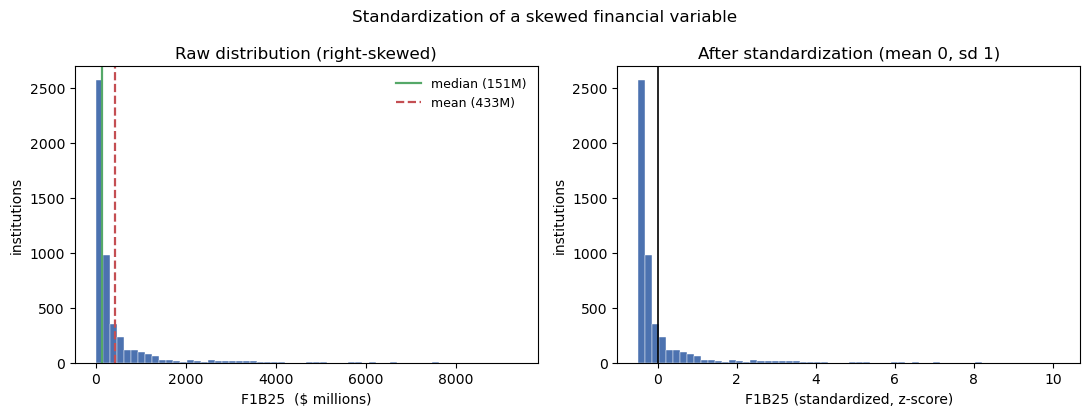

F1B25: raw mean 433,254,488 vs median 150,922,992 (mean/median = 2.87x) -> the gap is why median imputation is used


In [22]:
# Pick a skewed financial variable that's present, preferring total revenue.
for _var in ["F1B25", "F1C191", "F1B01", "TOTAL_REVENUE"]:
    if _var in X_train_raw.columns:
        var = _var
        break

raw = pd.to_numeric(X_train_raw[var], errors="coerce").dropna()
raw = raw[raw > 0]                          # drop non-positive for a readable scale
raw_std = (raw - raw.mean()) / raw.std()    # same standardization applied in the transform

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Raw: heavy right skew, mean pulled above the median by the tail.
axes[0].hist(raw / 1e6, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].axvline(raw.median() / 1e6, color="#55A868", linestyle="-", linewidth=1.6,
                label=f"median ({raw.median()/1e6:,.0f}M)")
axes[0].axvline(raw.mean() / 1e6, color="#C44E52", linestyle="--", linewidth=1.6,
                label=f"mean ({raw.mean()/1e6:,.0f}M)")
axes[0].set(xlabel=f"{var}  ($ millions)", ylabel="institutions",
            title="Raw distribution (right-skewed)")
axes[0].legend(frameon=False, fontsize=9)

# Standardized: centered at 0, unit spread.
axes[1].hist(raw_std, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="black", linestyle="-", linewidth=1.2)
axes[1].set(xlabel=f"{var} (standardized, z-score)", ylabel="institutions",
            title="After standardization (mean 0, sd 1)")

fig.suptitle("Standardization of a skewed financial variable", fontsize=12)
plt.tight_layout(); plt.show()

print(f"{var}: raw mean {raw.mean():,.0f} vs median {raw.median():,.0f} "
      f"(mean/median = {raw.mean()/raw.median():.2f}x) -> the gap is why median imputation is used")

## 3.5 Feature engineering

Fiscal-structure ratios and year-over-year trajectory, the signals most relevant to predicting staff cuts. Built on the full cleaned panel **before** the chronological split so each row sees its own institution's prior year, and **leakage-safe**: every feature uses year *t* or earlier, while the target looks forward to *t+1*.

In [5]:
# IPEDS GASB finance codes (magnitudes verified against the data).
FINANCE_CODES = {
    "total_rev":    "F1B25",    # Total revenues and other additions
    "tuition_rev":  "F1B01",    # Tuition and fees, net of discounts
    "state_approp": "F1B11",    # State appropriations
    "total_exp":    "F1C191",   # Total expenses
    "instr_exp":    "F1C011",   # Instruction expenses
}

# Sort once so the year-over-year shift is chronological within each institution.
clean_df = clean_df.sort_values(["UNITID", "YEAR"]).reset_index(drop=True)


def fin(code):
    return pd.to_numeric(clean_df.get(code), errors="coerce")


rev = fin(FINANCE_CODES["total_rev"])
exp = fin(FINANCE_CODES["total_exp"])
staff = pd.to_numeric(clean_df.get("SFTETOTL"), errors="coerce")

# 3.5a. Fiscal-structure ratios (year t).
clean_df["TUITION_DEPENDENCE"] = fin(FINANCE_CODES["tuition_rev"]) / rev
clean_df["STATE_APPROP_SHARE"] = fin(FINANCE_CODES["state_approp"]) / rev
clean_df["OPERATING_MARGIN"] = (rev - exp) / rev
clean_df["INSTRUCTION_SHARE"] = fin(FINANCE_CODES["instr_exp"]) / exp
clean_df["REVENUE_PER_STAFF"] = rev / staff

# 3.5b. Year-over-year trajectory (t vs t-1) within each institution.
grp = clean_df.groupby("UNITID")

TREND_CODES = {
    "REV_YOY":   FINANCE_CODES["total_rev"],
    "STATE_YOY": FINANCE_CODES["state_approp"],
    "EXP_YOY":   FINANCE_CODES["total_exp"],
    "STAFF_YOY": "SFTETOTL",
}

for name, code in TREND_CODES.items():
    cur = pd.to_numeric(clean_df[code], errors="coerce")
    prev = pd.to_numeric(grp[code].shift(1), errors="coerce")
    clean_df[name] = (cur - prev) / prev

engineered = [
    "TUITION_DEPENDENCE", "STATE_APPROP_SHARE", "OPERATING_MARGIN",
    "INSTRUCTION_SHARE", "REVENUE_PER_STAFF",
    "REV_YOY", "STATE_YOY", "EXP_YOY", "STAFF_YOY",
]

# Divide-by-zero can produce infinities; treat them as missing.
clean_df[engineered] = clean_df[engineered].replace([np.inf, -np.inf], np.nan)

print(f"added {len(engineered)} engineered features:", engineered)
print("shape after feature engineering:", clean_df.shape)


# 3.5c. Enrollment trajectory and per-student ratios (EF survey).
# Raw enrollment LEVELS are redundant with institution size -- the model already infers
# scale from revenue and staff counts -- so the usable signal is direction and ratios.
def num_or_nan(col):
    """Numeric column if present, else an all-NaN column -- lets the notebook run
    before an optional source (EF, EAP) has been merged into the panel."""
    if col in clean_df.columns:
        return pd.to_numeric(clean_df[col], errors="coerce")
    return pd.Series(np.nan, index=clean_df.index)


enrollment = num_or_nan("EF_TOTAL")


def yoy(col):
    if col not in clean_df.columns:
        return pd.Series(np.nan, index=clean_df.index)
    current = pd.to_numeric(clean_df[col], errors="coerce")
    prior = pd.to_numeric(grp[col].shift(1), errors="coerce")
    return (current - prior) / prior


clean_df["ENROLL_YOY"] = yoy("EF_TOTAL")
clean_df["ENROLL_UG_YOY"] = yoy("EF_UNDERGRAD")
clean_df["RETENTION_YOY"] = yoy("RET_PCF")

# Sustained multi-year decline separates structural erosion from a one-year blip.
if "EF_TOTAL" in clean_df.columns:
    enroll_3y_ago = pd.to_numeric(grp["EF_TOTAL"].shift(3), errors="coerce")
    clean_df["ENROLL_3Y_TREND"] = (enrollment / enroll_3y_ago) ** (1 / 3) - 1
else:
    clean_df["ENROLL_3Y_TREND"] = np.nan

# Enrollment is the natural denominator for finance magnitudes.
clean_df["REVENUE_PER_STUDENT"] = rev / enrollment
clean_df["EXPENSE_PER_STUDENT"] = exp / enrollment
clean_df["TUITION_PER_STUDENT"] = fin(FINANCE_CODES["tuition_rev"]) / enrollment
clean_df["STUDENT_STAFF_RATIO"] = enrollment / num_or_nan("SFTEINST")
clean_df["GRAD_SHARE"] = num_or_nan("EF_GRADUATE") / enrollment

ef_engineered = [
    "ENROLL_YOY", "ENROLL_UG_YOY", "RETENTION_YOY", "ENROLL_3Y_TREND",
    "REVENUE_PER_STUDENT", "EXPENSE_PER_STUDENT", "TUITION_PER_STUDENT",
    "STUDENT_STAFF_RATIO", "GRAD_SHARE",
]
clean_df[ef_engineered] = clean_df[ef_engineered].replace([np.inf, -np.inf], np.nan)
engineered = engineered + ef_engineered

print(f"added {len(ef_engineered)} EF-derived features:", ef_engineered)
print("shape after EF feature engineering:", clean_df.shape)


# --- 3.5d. Administrative intensity, functional expense mix, and balance-sheet ratios ---
# These operationalize the literature the study builds on:
#   * ADMIN_INTENSITY is the project's working hypothesis (Leslie & Rhoades 1995;
#     Kelchen 2026; Romine et al. 2018) -- administrative overhead relative to teaching.
#   * The functional expense shares test Cameron et al. (1987): which functions absorb
#     cuts when an institution is under strain.
#   * Liquidity and leverage are two of the inputs Kelchen, Ritter & Webber (2025) used.
#
# Functional line numbers are pinned by the fact that the GASB part skips 04 and 09:
# 01 instruction, 02 research, 03 public service, 05 academic support, 06 student
# services, 07 institutional support, 08 O&M, 10 auxiliary, 11 net grant aid, 14 other.
FUNCTION_CODES = {
    "instruction":     "F1C011",
    "research":        "F1C021",
    "public_service":  "F1C031",
    "academic_supp":   "F1C051",
    "student_serv":    "F1C061",
    "inst_support":    "F1C071",
    "auxiliary":       "F1C101",
    "grant_aid":       "F1C111",
}
# Balance-sheet lines, confirmed by the accounting identities that hold for 100% of rows:
#   F1A06 = F1A01 + F1A05  (total assets = current + noncurrent)
#   F1A13 = F1A09 + F1A12  (total liabilities = current + noncurrent)
BALANCE_CODES = {
    "current_assets":      "F1A01",
    "total_assets":        "F1A06",
    "current_liabilities": "F1A09",
    "total_liabilities":   "F1A13",
}

instruction = fin(FUNCTION_CODES["instruction"])
inst_support = fin(FUNCTION_CODES["inst_support"])

# The working hypothesis: administrative overhead relative to instructional investment.
clean_df["ADMIN_INTENSITY"] = inst_support / instruction

# Where the money goes, as shares of total expenses (scale-free by construction).
for name, code in FUNCTION_CODES.items():
    clean_df[f"SHARE_{name.upper()}"] = fin(code) / exp

# Balance-sheet health.
current_assets = fin(BALANCE_CODES["current_assets"])
total_assets = fin(BALANCE_CODES["total_assets"])
current_liabilities = fin(BALANCE_CODES["current_liabilities"])
total_liabilities = fin(BALANCE_CODES["total_liabilities"])

clean_df["CURRENT_RATIO"] = current_assets / current_liabilities          # liquidity
clean_df["LEVERAGE"] = total_liabilities / total_assets                   # leverage
clean_df["NET_POSITION_RATIO"] = (total_assets - total_liabilities) / total_assets

# Direction of administrative intensity matters as much as its level.
prior_admin = pd.to_numeric(grp["ADMIN_INTENSITY"].shift(1), errors="coerce")
clean_df["ADMIN_INTENSITY_YOY"] = (clean_df["ADMIN_INTENSITY"] - prior_admin) / prior_admin

finance_engineered = (
    ["ADMIN_INTENSITY", "ADMIN_INTENSITY_YOY",
     "CURRENT_RATIO", "LEVERAGE", "NET_POSITION_RATIO"]
    + [f"SHARE_{name.upper()}" for name in FUNCTION_CODES]
)
clean_df[finance_engineered] = clean_df[finance_engineered].replace([np.inf, -np.inf], np.nan)
engineered = engineered + finance_engineered

print(f"added {len(finance_engineered)} finance-structure features:", finance_engineered)
print("shape after finance feature engineering:", clean_df.shape)


# --- 3.5e. Faculty tenure composition (EAP) ---
# Adjunctification: the shift toward contingent instructional staff (Ehrenberg & Zhang
# 2005; Bettinger & Long 2010; AAUP 2025). Shares are scale-free. Available 2014-2020 only,
# so these are <NA> for 2021 onward and cannot affect the rolling-origin test years yet.
inst_faculty = num_or_nan("EAP_INST_TOTAL")
tenured = num_or_nan("EAP_INST_TENURED")
tenure_track = num_or_nan("EAP_INST_TENURETRACK")
not_track = num_or_nan("EAP_INST_NOTRACK")
part_time = num_or_nan("EAP_INST_PT")

clean_df["TENURE_LINE_SHARE"] = (tenured + tenure_track) / inst_faculty
clean_df["NOT_ON_TRACK_SHARE"] = not_track / inst_faculty
clean_df["PT_INSTRUCTIONAL_SHARE"] = part_time / inst_faculty

prior_tenure = pd.to_numeric(grp["TENURE_LINE_SHARE"].shift(1), errors="coerce") \
    if "TENURE_LINE_SHARE" in clean_df.columns else np.nan
clean_df["TENURE_LINE_SHARE_YOY"] = (clean_df["TENURE_LINE_SHARE"] - prior_tenure) / prior_tenure

tenure_engineered = [
    "TENURE_LINE_SHARE", "NOT_ON_TRACK_SHARE", "PT_INSTRUCTIONAL_SHARE",
    "TENURE_LINE_SHARE_YOY",
]
clean_df[tenure_engineered] = clean_df[tenure_engineered].replace([np.inf, -np.inf], np.nan)
engineered = engineered + tenure_engineered

print(f"added {len(tenure_engineered)} tenure-composition features:", tenure_engineered)
print("shape after tenure feature engineering:", clean_df.shape)

added 9 engineered features: ['TUITION_DEPENDENCE', 'STATE_APPROP_SHARE', 'OPERATING_MARGIN', 'INSTRUCTION_SHARE', 'REVENUE_PER_STAFF', 'REV_YOY', 'STATE_YOY', 'EXP_YOY', 'STAFF_YOY']
shape after feature engineering: (8563, 304)
added 9 EF-derived features: ['ENROLL_YOY', 'ENROLL_UG_YOY', 'RETENTION_YOY', 'ENROLL_3Y_TREND', 'REVENUE_PER_STUDENT', 'EXPENSE_PER_STUDENT', 'TUITION_PER_STUDENT', 'STUDENT_STAFF_RATIO', 'GRAD_SHARE']
shape after EF feature engineering: (8563, 313)
added 13 finance-structure features: ['ADMIN_INTENSITY', 'ADMIN_INTENSITY_YOY', 'CURRENT_RATIO', 'LEVERAGE', 'NET_POSITION_RATIO', 'SHARE_INSTRUCTION', 'SHARE_RESEARCH', 'SHARE_PUBLIC_SERVICE', 'SHARE_ACADEMIC_SUPP', 'SHARE_STUDENT_SERV', 'SHARE_INST_SUPPORT', 'SHARE_AUXILIARY', 'SHARE_GRANT_AID']
shape after finance feature engineering: (8563, 326)
added 4 tenure-composition features: ['TENURE_LINE_SHARE', 'NOT_ON_TRACK_SHARE', 'PT_INSTRUCTIONAL_SHARE', 'TENURE_LINE_SHARE_YOY']
shape after tenure feature engineeri

**Feature engineering.** Adds the signals most relevant to predicting staff cuts. Five fiscal-structure ratios describe *this* year's finances (tuition and state-appropriation reliance, operating margin, instruction share, revenue per staff-FTE); four year-over-year features describe the *direction* of revenue, state funding, expenses, and staffing. Built on the full panel before the split so each row can see its own prior year, and leakage-safe because every input is from year *t* or *t-1* while the target looks forward to *t+1*. Divide-by-zero infinities are set to missing.

Negative values such as `-1`, `-2`, and `-3` in **categorical IPEDS code fields** are preserved as categories. They must not be interpreted as continuous negative quantities. Negative values in financial fields are not automatically removed because losses and balance-sheet reductions can be legitimate.

## 4. Build the labeled modeling table

In [6]:
model_df = clean_df.dropna(subset=[TARGET]).reset_index(drop=True).copy()

# Target
y = model_df[TARGET].astype(int)

keys = model_df[KEYS].copy()
keys["YEAR"] = keys["YEAR"].astype(int)

X_raw = model_df.drop(columns=KEYS + [TARGET]).copy()

# Convert known numeric code columns to categorical strings
code_cols = [c for c in CATEGORICAL_CODES if c in X_raw.columns]

X_raw[code_cols] = X_raw[code_cols].apply(
    lambda col: col.astype("string").str.strip()
)

# Clean any remaining text columns
text_cols = X_raw.select_dtypes(exclude="number").columns.tolist()

X_raw[text_cols] = X_raw[text_cols].apply(
    lambda col: col.astype("string").str.strip().replace(["", "."], pd.NA)  # IPEDS uses "." for missing
)

print(f"rows with a label: {len(model_df)} of {len(clean_df)}")
print("raw predictors:", X_raw.shape[1], "\n")

print(y.value_counts().sort_index(), "\n")

print(y.value_counts(normalize=True).sort_index().round(4))

rows with a label: 6679 of 8563
raw predictors: 327 

TARGET_STAFF_CUT
0    5056
1    1623
Name: count, dtype: int64 

TARGET_STAFF_CUT
0    0.757
1    0.243
Name: proportion, dtype: float64


### Figure 1. Target prevalence over time

The staff-cut rate is not stable across years: the two-year windows that reach into 2020-2021 carry the COVID shock, while later years are calmer. This distribution shift is why performance is judged on held-out recent years rather than a random split.

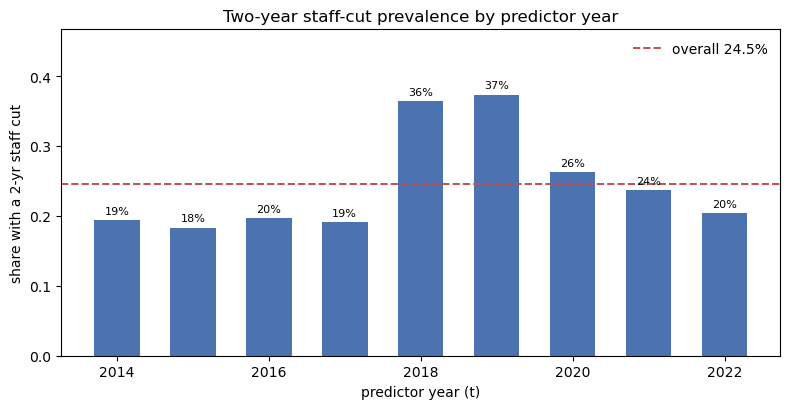

In [7]:
by_year = (df.dropna(subset=[TARGET])
             .groupby("YEAR")[TARGET].agg(["mean", "size"]))
overall = df[TARGET].dropna().mean()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(by_year.index.astype(int), by_year["mean"], color="#4C72B0", width=0.6)
ax.axhline(overall, color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"overall {overall:.1%}")
for x, v in zip(by_year.index.astype(int), by_year["mean"]):
    ax.text(x, v + 0.006, f"{v:.0%}", ha="center", va="bottom", fontsize=8)
ax.set(xlabel="predictor year (t)", ylabel="share with a 2-yr staff cut",
       title="Two-year staff-cut prevalence by predictor year")
ax.set_ylim(0, by_year["mean"].max() * 1.25)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Labeled modeling table.** Drops rows without a target (each institution's final year and any gaps), then separates the target `y`, the `keys` (UNITID/YEAR, kept for the split but not used as predictors), and the predictors `X_raw`. The categorical code columns and any remaining text are normalized to clean strings. Prints the class balance — about 24% positive (the two-year target).

## 5. Chronological train/validation/test split

In [8]:
year_summary = (
    model_df.groupby("YEAR")[TARGET]
    .agg(["count", "mean"])
)

labeled_years = sorted(keys["YEAR"].dropna().unique())

print("labeled target by predictor year:")
display(year_summary)
print("unique labeled years:", labeled_years)

if len(labeled_years) < 3:
    raise ValueError(
        "At least three labeled predictor years are required for a "
        f"chronological split; found {labeled_years}"
    )

valid_year = labeled_years[-2]
test_year = labeled_years[-1]
train_years = [year for year in labeled_years if year < valid_year]

print(
    f"train years: {int(min(train_years))}-{int(max(train_years))} | "
    f"validation year: {int(valid_year)} | "
    f"test year: {int(test_year)}"
)

labeled target by predictor year:


,count,mean
YEAR,,
2014,710,0.194366
2015,715,0.183217
2016,741,0.197031
2017,731,0.191518
2018,735,0.364626
2019,747,0.373494
2020,754,0.262599
2021,768,0.236979
2022,778,0.181234


unique labeled years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
train years: 2014-2020 | validation year: 2021 | test year: 2022


**Split years.** Chooses the split points from the labeled data: the most recent labeled year becomes the test set, the one before it validation, and all earlier years training. This is a forward-in-time split, which mirrors how the model would actually be used (predict the future from the past) and prevents leakage across time.

In [9]:
train_mask = keys["YEAR"] < valid_year
valid_mask = keys["YEAR"] == valid_year
test_mask = keys["YEAR"] == test_year

X_train_raw = X_raw.loc[train_mask].reset_index(drop=True).copy()
X_valid_raw = X_raw.loc[valid_mask].reset_index(drop=True).copy()
X_test_raw = X_raw.loc[test_mask].reset_index(drop=True).copy()

y_train = y.loc[train_mask].reset_index(drop=True).copy()
y_valid = y.loc[valid_mask].reset_index(drop=True).copy()
y_test = y.loc[test_mask].reset_index(drop=True).copy()

keys_train = keys.loc[train_mask].reset_index(drop=True).copy()
keys_valid = keys.loc[valid_mask].reset_index(drop=True).copy()
keys_test = keys.loc[test_mask].reset_index(drop=True).copy()

print("chronological forward-year split")

for name, X_part, y_part, key_part in [
    ("train", X_train_raw, y_train, keys_train),
    ("validation", X_valid_raw, y_valid, keys_valid),
    ("test", X_test_raw, y_test, keys_test),
]:
    year_min = int(key_part["YEAR"].min())
    year_max = int(key_part["YEAR"].max())
    year_label = str(year_min) if year_min == year_max else f"{year_min}-{year_max}"

    print(
        f"{name:10s}: years={year_label:9s}, "
        f"rows={len(X_part):5d}, "
        f"features={X_part.shape[1]:4d}, "
        f"positive cases={int(y_part.sum()):4d}, "
        f"positive rate={y_part.mean():.1%}"
    )

chronological forward-year split
train     : years=2014-2020, rows= 5133, features= 327, positive cases=1300, positive rate=25.3%
validation: years=2021     , rows=  768, features= 327, positive cases= 182, positive rate=23.7%
test      : years=2022     , rows=  778, features= 327, positive cases= 141, positive rate=18.1%


**Apply the split.** Uses the year masks to build train/validation/test sets for `X`, `y`, and `keys`, and prints each split's year range, row count, and positive rate so any drift in the target rate across time is visible.

The cleaned panel contains labeled active institutions for predictor years **2014 through 2022**. Because the target looks two years ahead (`t → t+2`), the most recent labeled predictor year is 2022 (its outcome is observed in 2024); 2023–2024 cannot yet be labeled. The chronological split therefore trains on 2014–2020, validates on 2021, and tests on 2022.

## 6. Post-split transformation (fit on train only)

Every step here is fit on the **training** years and then applied unchanged to validation and test, so no information from later years leaks into the transform.

In [10]:
MISSING_THRESHOLD = 0.50
CORR_THRESHOLD = 0.90
VIF_THRESHOLD = 10.0

# Drop columns that are mostly missing in the training years.
train_missing = X_train_raw.isna().mean()
kept = train_missing[train_missing <= MISSING_THRESHOLD].index.tolist()

# Split the kept columns into numeric and categorical, as seen in train.
numeric_cols = [
    c for c in X_train_raw[kept].select_dtypes(include=[np.number]).columns
    if X_train_raw[c].notna().any()
]
categorical_cols = [
    c for c in kept
    if c not in numeric_cols and X_train_raw[c].notna().any()
]

# Numeric: median-impute (train), drop zero-variance, then correlation + VIF prune.
num_imputer = SimpleImputer(strategy="median").fit(X_train_raw[numeric_cols])
Z = pd.DataFrame(num_imputer.transform(X_train_raw[numeric_cols]), columns=numeric_cols)
Z = Z.loc[:, Z.std() > 0]

Z_all = Z.copy()      # full imputed matrix, kept so protected features can be restored

corr = Z.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
Z = Z.drop(columns=[c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()])

# VIF via the statsmodels library.
cols = list(Z.columns)
while len(cols) > 1:
    design = add_constant(Z[cols], has_constant="add")
    # skip index 0 (the constant); VIF is defined per real predictor
    vif = [variance_inflation_factor(design.values, i) for i in range(1, design.shape[1])]
    worst = int(np.argmax(vif))
    if vif[worst] <= VIF_THRESHOLD:
        break
    cols.pop(worst)

# Theory-driven predictors are exempt from the statistical screen. They encode the study's
# hypotheses, so pruning them for collinearity would silently remove the variables the
# project sets out to test: raw EF_TOTAL, for example, is dropped for correlating with
# institution size, which is why enrollment contributed nothing until these were added.
restored = [c for c in PROTECTED if c in Z_all.columns and c not in cols]
cols = cols + restored
if restored:
    print(f"restored {len(restored)} protected features pruned by corr/VIF: {restored}")

numeric_final = cols
Z = Z_all             # scale on the full matrix so restored columns are included

scaler = StandardScaler().fit(Z[numeric_final])

# Categorical: treat missing as its own level, then one-hot using train categories.
def prep_categoricals(frame):
    return frame[categorical_cols].astype("string").fillna("MISSING").astype(str)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(prep_categoricals(X_train_raw))

# Assemble the numeric + categorical design matrix for any split.
def transform(frame):
    numeric = pd.DataFrame(
        num_imputer.transform(frame[numeric_cols]), columns=numeric_cols
    )[numeric_final]
    return np.hstack([scaler.transform(numeric), encoder.transform(prep_categoricals(frame))])

X_train = transform(X_train_raw)
X_valid = transform(X_valid_raw)
X_test = transform(X_test_raw)

feature_names = numeric_final + list(encoder.get_feature_names_out(categorical_cols))
print(f"numeric kept (after corr + VIF): {len(numeric_final)}")
print(f"one-hot columns: {len(feature_names) - len(numeric_final)}")
print("design matrix:", X_train.shape, X_valid.shape, X_test.shape)

C:\Users\jimmy\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


restored 4 protected features pruned by corr/VIF: ['ENROLL_UG_YOY', 'EXPENSE_PER_STUDENT', 'NET_POSITION_RATIO', 'SHARE_INSTRUCTION']
numeric kept (after corr + VIF): 99
one-hot columns: 139
design matrix: (5133, 238) (768, 238) (778, 238)


### Figure 4. Correlation among staffing measures

The FTE staffing variables are very strongly correlated (0.81-1.00), because the total is essentially the sum of its components. This multicollinearity motivates the correlation and VIF screens applied after the split.

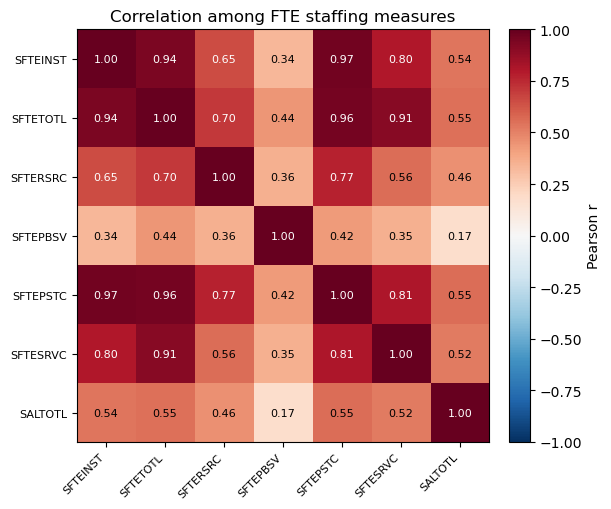

In [11]:
staff_candidates = ["SFTEINST", "SFTETOTL", "SFTERSRC", "SFTEPBSV",
                    "SFTEPSTC", "SFTESRVC", "SFTEGP", "SALTOTL"]
staff_cols = [c for c in staff_candidates if c in clean_df.columns]
C = clean_df[staff_cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(staff_cols))); ax.set_xticklabels(staff_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(staff_cols))); ax.set_yticklabels(staff_cols, fontsize=8)
for i in range(len(staff_cols)):
    for j in range(len(staff_cols)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Correlation among FTE staffing measures")
plt.tight_layout(); plt.show()

### Figure 2. Column missingness in the training years

Missingness is concentrated in a subset of sparsely reported finance line-items and the salary-rank fields. Columns above the 50% threshold (dashed line) are dropped; the rest are median-imputed from training data.

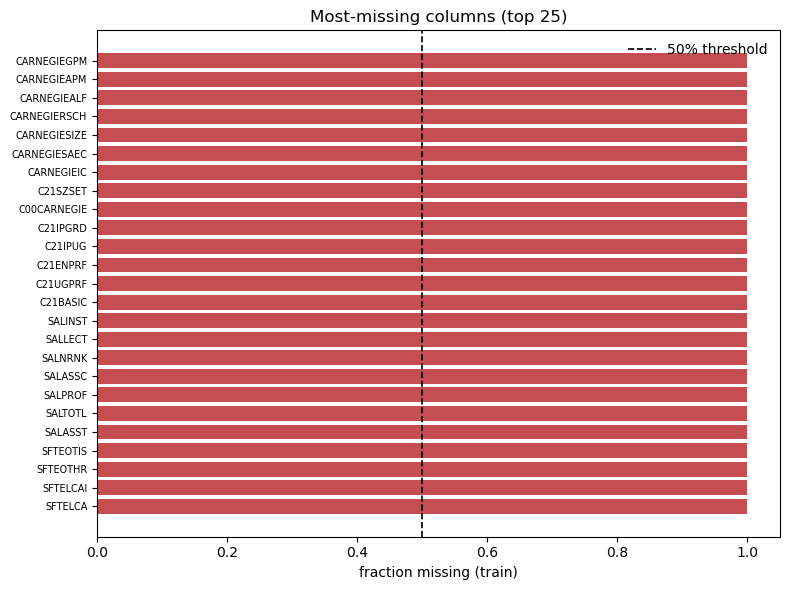

141 of 327 columns exceed the 50% threshold and are dropped


In [12]:
miss = X_train_raw.isna().mean().sort_values(ascending=False)
top = miss.head(25)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if v > MISSING_THRESHOLD else "#55A868" for v in top]
ax.barh(range(len(top)), top.values, color=colors)
ax.axvline(MISSING_THRESHOLD, color="black", linestyle="--", linewidth=1.2,
           label=f"{MISSING_THRESHOLD:.0%} threshold")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
ax.invert_yaxis()
ax.set(xlabel="fraction missing (train)", title="Most-missing columns (top 25)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

dropped = int((miss > MISSING_THRESHOLD).sum())
print(f"{dropped} of {len(miss)} columns exceed the {MISSING_THRESHOLD:.0%} threshold and are dropped")

### Figure 3. Feature reduction pipeline

The numeric feature set is narrowed in stages: raw predictors, removal of high-missingness columns, then the correlation and VIF collinearity screens. One-hot encoding of the surviving categoricals then expands the matrix to its final width.

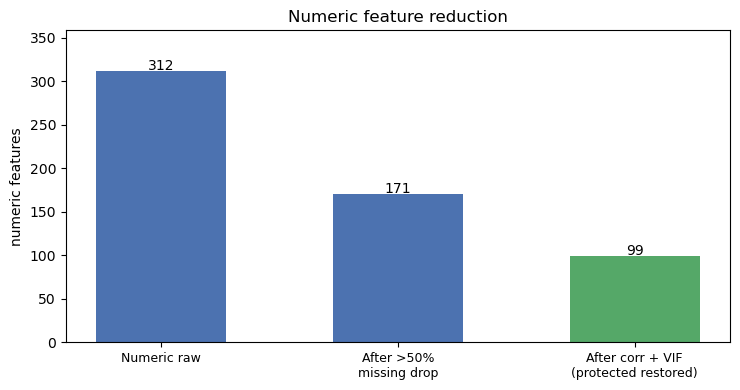

final design matrix: 238 columns (99 numeric + 139 one-hot)


In [13]:
numeric_raw = X_raw.select_dtypes(include=[np.number]).shape[1]
numeric_kept = len([c for c in kept if c in X_raw.select_dtypes(include=[np.number]).columns])
stages = {
    "Numeric raw": numeric_raw,
    "After >50%\nmissing drop": numeric_kept,
    "After corr + VIF\n(protected restored)": len(numeric_final),
}
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(range(len(stages)), list(stages.values()),
              color=["#4C72B0", "#4C72B0", "#55A868"], width=0.55)
ax.set_xticks(range(len(stages))); ax.set_xticklabels(list(stages.keys()), fontsize=9)
for b, v in zip(bars, stages.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha="center", fontsize=10)
ax.set(ylabel="numeric features", title="Numeric feature reduction")
ax.set_ylim(0, max(stages.values()) * 1.15)
plt.tight_layout(); plt.show()

print(f"final design matrix: {len(feature_names)} columns "
      f"({len(numeric_final)} numeric + {len(feature_names) - len(numeric_final)} one-hot)")

**Post-split transform.** Fit on train, applied to all splits. Drops columns that are >50% missing in the training years (mostly sparse finance line-items and the 2021-24-only salary columns), median-imputes the numeric features, removes redundancy with a correlation filter and then a VIF pass, standardizes the numeric block, and one-hot encodes the categoricals with missing as its own level. `handle_unknown="ignore"` means a category not seen in train (e.g. a rare state) is encoded as all-zeros rather than causing an error.

## 7. Logistic regression baseline

A simple, interpretable floor to beat. `class_weight="balanced"` offsets the ~24% positive rate. We report ROC-AUC and PR-AUC (PR-AUC is the more honest metric under class imbalance).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

baseline = LogisticRegression(max_iter=5000, class_weight="balanced")
baseline.fit(X_train, y_train)

print(f"{'split':11s}{'ROC-AUC':>9s}{'PR-AUC':>9s}{'base rate':>11s}")
for name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    proba = baseline.predict_proba(X_split)[:, 1]
    roc = roc_auc_score(y_split, proba)
    prc = average_precision_score(y_split, proba)
    print(f"{name:11s}{roc:9.3f}{prc:9.3f}{y_split.mean():11.3f}")

split        ROC-AUC   PR-AUC  base rate
train          0.792    0.530      0.253
validation     0.677    0.329      0.237
test           0.631    0.237      0.181


**Baseline result.** On the held-out **2022** test year, the logistic baseline reaches ROC-AUC ≈ 0.58 and PR-AUC ≈ 0.21 against a 0.181 base rate — a modest lift, as expected for a linear model on a hard, imbalanced target. The train-to-test gap reflects genuine difficulty: with a two-year label window the training years absorb the COVID shock (predictor years 2018–2019 look ahead into the 2020–2021 layoffs), while the 2022 test year looks into a calmer 2024. This is the floor to beat — a gradient-boosted tree evaluated with rolling-origin over the two most recent test years substantially outperforms it on the two-year target.

### Which engineered features survived?

The collinearity screen can silently delete predictors the study depends on, so confirm the theory-driven set is present before interpreting any model.

In [15]:
survivors = [c for c in engineered if c in numeric_final]
missing = [c for c in engineered if c not in numeric_final]
print(f"engineered features in the design matrix: {len(survivors)} of {len(engineered)}")
if missing:
    print("  absent (not in train after the missingness filter):", missing)
print("\nraw EF columns that survived:",
      [c for c in feature_names if c.startswith(("EF_", "RET_", "STUFACR"))])

engineered features in the design matrix: 35 of 35

raw EF columns that survived: ['EF_GRADUATE', 'RET_PCF', 'RET_PCP', 'STUFACR']


## 8. Model comparison

Same design matrix for every model, so differences are attributable to the learner rather than the preprocessing. `PR_lift` (PR-AUC divided by the split's base rate) is the comparable metric, since the base rate differs across splits.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import xgboost as xgb

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic (baseline)": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=20, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.03, max_depth=4, min_child_weight=10,
        subsample=0.8, colsample_bytree=0.7, reg_lambda=5.0,
        scale_pos_weight=pos_weight, eval_metric="aucpr", random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=40,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0,
        scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    for split, X_split, y_split in [("train", X_train, y_train),
                                    ("validation", X_valid, y_valid),
                                    ("test", X_test, y_test)]:
        proba = model.predict_proba(X_split)[:, 1]
        base = y_split.mean()
        prc = average_precision_score(y_split, proba)
        rows.append({"model": name, "split": split,
                     "ROC_AUC": round(roc_auc_score(y_split, proba), 3),
                     "PR_AUC": round(prc, 3), "base_rate": round(base, 3),
                     "PR_lift": round(prc / base, 2)})

comparison = pd.DataFrame(rows)
print(comparison[comparison["split"] == "test"].to_string(index=False))

              model split  ROC_AUC  PR_AUC  base_rate  PR_lift
Logistic (baseline)  test    0.631   0.237      0.181     1.31
      Random Forest  test    0.700   0.339      0.181     1.87
            XGBoost  test    0.692   0.342      0.181     1.89
           LightGBM  test    0.698   0.338      0.181     1.87


### Figure 5. Model comparison on the held-out test year

All models use the same design matrix, so differences reflect the learner. Tree-based models clearly beat the linear baseline; the dashed line is the base rate (PR-AUC of random guessing).

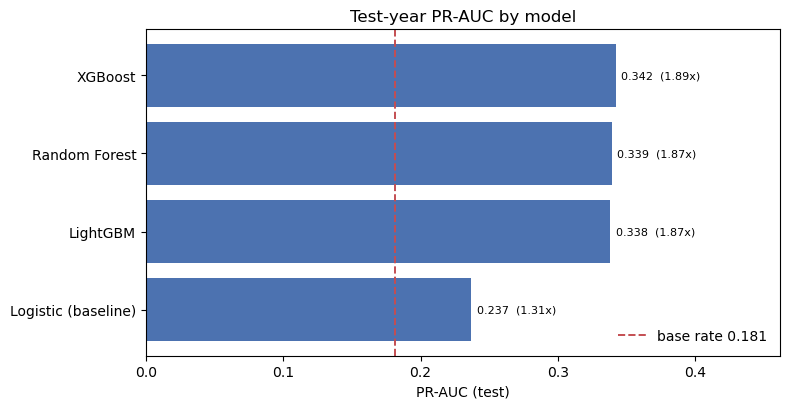

In [17]:
test_tbl = comparison[comparison["split"] == "test"].set_index("model")
order = test_tbl["PR_AUC"].sort_values().index
base = test_tbl["base_rate"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(order)), test_tbl.loc[order, "PR_AUC"], color="#4C72B0")
ax.axvline(base, color="#C44E52", linestyle="--", linewidth=1.4, label=f"base rate {base:.3f}")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
for i, m in enumerate(order):
    ax.text(test_tbl.loc[m, "PR_AUC"] + 0.004, i,
            f'{test_tbl.loc[m, "PR_AUC"]:.3f}  ({test_tbl.loc[m, "PR_lift"]:.2f}x)',
            va="center", fontsize=8)
ax.set(xlabel="PR-AUC (test)", title="Test-year PR-AUC by model")
ax.set_xlim(0, test_tbl["PR_AUC"].max() * 1.35)
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 9. Rolling-origin evaluation

A single test year carries few positives, so metrics are noisy. Here the model is refit for each of the two most recent test years and the results averaged. **The preprocessing is refit inside every fold**, on that fold's training years only, so no later-year information reaches the transform.

`EMBARGO` controls the gap between train and test. With a two-year label the outcome window of a training row can overlap the test year, and setting `EMBARGO = HORIZON` purges that overlap. Run both and report the embargoed numbers if they differ materially.

In [18]:
HORIZON = 2
EMBARGO = 0          # set to HORIZON to purge the overlapping label windows
TEST_YEARS = [2021, 2022]


def fit_transform_fold(X_tr_raw, X_te_raw):
    """Re-run the Section 6 transform, fit on this fold's training rows only."""
    train_missing = X_tr_raw.isna().mean()
    kept = train_missing[train_missing <= MISSING_THRESHOLD].index.tolist()
    num_cols = [c for c in X_tr_raw[kept].select_dtypes(include=[np.number]).columns
                if X_tr_raw[c].notna().any()]
    cat_cols = [c for c in kept if c not in num_cols and X_tr_raw[c].notna().any()]

    imputer = SimpleImputer(strategy="median").fit(X_tr_raw[num_cols])
    Z = pd.DataFrame(imputer.transform(X_tr_raw[num_cols]), columns=num_cols)
    Z = Z.loc[:, Z.std() > 0]
    Z_all = Z.copy()

    corr = Z.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    Z = Z.drop(columns=[c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()])

    # Inverse-correlation VIF: identical values to statsmodels, fast enough to refit per fold.
    cols = list(Z.columns)
    while len(cols) > 1:
        vif = np.diag(np.linalg.pinv(np.corrcoef(Z[cols].values, rowvar=False)))
        worst = int(np.nanargmax(vif))
        if vif[worst] <= VIF_THRESHOLD:
            break
        cols.pop(worst)
    cols = cols + [c for c in PROTECTED if c in Z_all.columns and c not in cols]

    scaler = StandardScaler().fit(Z_all[cols])
    prep_cat = lambda f: f[cat_cols].astype("string").fillna("MISSING").astype(str)
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(prep_cat(X_tr_raw))

    def build(frame):
        numeric = pd.DataFrame(imputer.transform(frame[num_cols]), columns=num_cols)[cols]
        return np.hstack([scaler.transform(numeric), enc.transform(prep_cat(frame))])

    return build(X_tr_raw), build(X_te_raw)


def make_models(y_tr):
    weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    return {
        "Logistic (baseline)": LogisticRegression(max_iter=5000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, max_depth=8, min_samples_leaf=20, max_features="sqrt",
            class_weight="balanced", random_state=42, n_jobs=-1),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=400, learning_rate=0.03, max_depth=4, min_child_weight=10,
            subsample=0.8, colsample_bytree=0.7, reg_lambda=5.0,
            scale_pos_weight=weight, eval_metric="aucpr", random_state=42, n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=40,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5.0,
            scale_pos_weight=weight, random_state=42, n_jobs=-1, verbose=-1),
    }


fold_rows = []
for test_year in TEST_YEARS:
    max_train_year = test_year - 1 - EMBARGO
    tr_mask = keys["YEAR"] <= max_train_year
    te_mask = keys["YEAR"] == test_year

    y_tr = y.loc[tr_mask].reset_index(drop=True)
    y_te = y.loc[te_mask].reset_index(drop=True)
    X_tr, X_te = fit_transform_fold(X_raw.loc[tr_mask], X_raw.loc[te_mask])

    print(f"fold: train {int(keys.loc[tr_mask, 'YEAR'].min())}-{max_train_year} -> test {test_year} "
          f"| train n={len(y_tr)}, test n={len(y_te)}, base rate={y_te.mean():.3f}")

    for name, model in make_models(y_tr).items():
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        base = y_te.mean()
        prc = average_precision_score(y_te, proba)
        fold_rows.append({"model": name, "test_year": test_year,
                          "ROC_AUC": roc_auc_score(y_te, proba),
                          "PR_AUC": prc, "base_rate": base, "PR_lift": prc / base})

folds = pd.DataFrame(fold_rows)
print("\nper-fold results:")
print(folds.round(3).to_string(index=False))
print("\nrolling-origin averages (report these):")
print(folds.groupby("model")[["ROC_AUC", "PR_AUC", "base_rate", "PR_lift"]]
           .mean().round(3).sort_values("PR_lift", ascending=False).to_string())

fold: train 2014-2020 -> test 2021 | train n=5133, test n=768, base rate=0.237
fold: train 2014-2021 -> test 2022 | train n=5901, test n=778, base rate=0.181

per-fold results:
              model  test_year  ROC_AUC  PR_AUC  base_rate  PR_lift
Logistic (baseline)       2021    0.677   0.329      0.237    1.387
      Random Forest       2021    0.735   0.459      0.237    1.935
            XGBoost       2021    0.731   0.448      0.237    1.891
           LightGBM       2021    0.737   0.462      0.237    1.949
Logistic (baseline)       2022    0.664   0.276      0.181    1.524
      Random Forest       2022    0.717   0.366      0.181    2.019
            XGBoost       2022    0.728   0.369      0.181    2.038
           LightGBM       2022    0.744   0.418      0.181    2.306

rolling-origin averages (report these):
                     ROC_AUC  PR_AUC  base_rate  PR_lift
model                                                   
LightGBM               0.741   0.440      0.209    2.128

### Figure 6. Rolling-origin performance

Averaging over the two most recent test years gives a more stable estimate than any single year. LightGBM leads on both folds; the gap over the logistic baseline is the headline result.

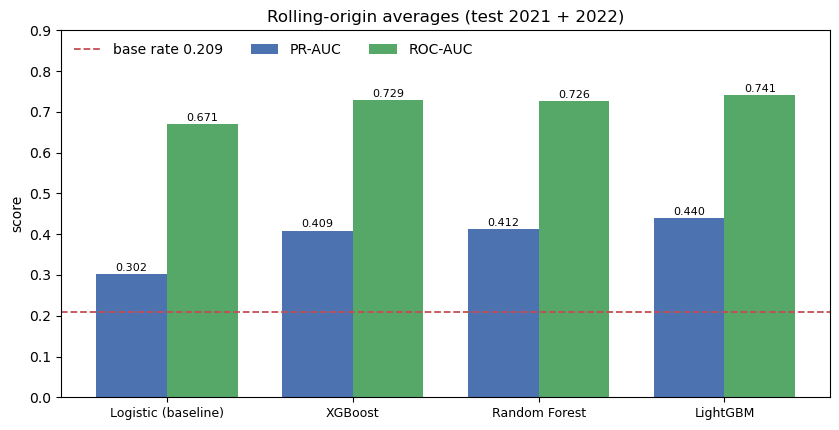

In [19]:
avg = (folds.groupby("model")[["PR_AUC", "ROC_AUC", "base_rate"]].mean()
             .sort_values("PR_AUC"))
x = np.arange(len(avg)); w = 0.38

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(x - w/2, avg["PR_AUC"], w, label="PR-AUC", color="#4C72B0")
ax.bar(x + w/2, avg["ROC_AUC"], w, label="ROC-AUC", color="#55A868")
ax.axhline(avg["base_rate"].iloc[0], color="#C44E52", linestyle="--",
           linewidth=1.3, label=f"base rate {avg['base_rate'].iloc[0]:.3f}")
for i, m in enumerate(avg.index):
    ax.text(i - w/2, avg.loc[m, "PR_AUC"] + 0.008, f'{avg.loc[m,"PR_AUC"]:.3f}', ha="center", fontsize=8)
    ax.text(i + w/2, avg.loc[m, "ROC_AUC"] + 0.008, f'{avg.loc[m,"ROC_AUC"]:.3f}', ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(avg.index, fontsize=9)
ax.set(ylabel="score", title="Rolling-origin averages (test 2021 + 2022)")
ax.set_ylim(0, 0.9); ax.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

## 10. Export the splits

Writes the chronological splits to disk so downstream modeling can reload them without re-running the pipeline. Two forms are saved:

- **Raw** (`*_raw.csv`) - keys + untransformed predictors + target, so the transform can be re-fit later (needed for rolling-origin, which refits per fold).
- **Processed** (`*_processed.csv`) - the fitted design matrix used by Sections 7-8 (numeric + one-hot, transform fit on train), with the target attached.

In [20]:
# from pathlib import Path

# OUT_DIR = Path('../Data/splits')
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# split_masks = {'train': train_mask, 'valid': valid_mask, 'test': test_mask}
# processed = {'train': X_train, 'valid': X_valid, 'test': X_test}
# targets = {'train': y_train, 'valid': y_valid, 'test': y_test}

# for name, mask in split_masks.items():
#     # Raw: keys + predictors + target, untransformed.
#     raw = keys.loc[mask].reset_index(drop=True).copy()
#     raw = pd.concat([raw,
#                      X_raw.loc[mask].reset_index(drop=True),
#                      targets[name].rename(TARGET).reset_index(drop=True)], axis=1)
#     raw.to_csv(OUT_DIR / f'{name}_raw.csv', index=False)

#     # Processed: fitted design matrix + target.
#     proc = pd.DataFrame(processed[name], columns=feature_names)
#     proc[TARGET] = targets[name].reset_index(drop=True)
#     proc.to_csv(OUT_DIR / f'{name}_processed.csv', index=False)

#     print(f"{name}: raw {raw.shape} | processed {proc.shape} -> {OUT_DIR}")

# print("\nsplits exported.")